# Mapowanie zasięgu stacji komórkowej za pomocą powierzchni konturowej tłumienia trasy


## Streszczenie

Zespół planowania radiowego telekomu renderuje **powierzchnię tłumienia trasy** downlinku wokół pojedynczej stacji makrokomórkowej jako dwuwymiarową mapę zasięgu. Wykorzystując logarytmiczno-odległościowy model propagacji z log-normalnym zanikiem cieniowym, ten notebook buduje siatkę pomiarową 100 punktów (10 x 10 komórek obejmujących obszar usługowy 10 km x 10 km, z wieżą w centrum) i rysuje wypełnioną powierzchnię konturową za pomocą **PROC SGPLOT HEATMAPPARM** wraz z gradientową skalą kolorów i liniami odniesienia wieży.

Na wykonanej siatce tłumienie trasy przebiega od **50,4 dB** (w jasnym zagłębieniu przy wieży) do **90,0 dB** w najdalszym rogu, ze średnią **75,6 dB**. Klasyfikacja każdej komórki według jej tłumienia daje **38 komórek Silny, 61 Umiarkowany i 1 Słaby**; jedyna komórka Słaby znajduje się w **(9,5, 9,5) km — rogu leżącym po przekątnej naprzeciw wieży — przy 89,97 dB**, jedyna dziura w zasięgu, którą planista oznaczyłby przed decyzją o dobudowie small-cell.


> **Uwaga dotycząca procedury.** W SAS klasycznym narzędziem do map konturowych izolinii jest `PROC GCONTOUR`. Jenner parsuje GCONTOUR i emituje poprawną specyfikację wykresu, ale jego renderer rastrowy nie rysuje jeszcze geometrii konturu (obraz wraca pusty); ten defekt jest zarejestrowany jako test regresyjny `tests/400922_nb_gcontour_empty_render`. Aby ten przykład w pełni opierał się na realnie wyrenderowanej figurze, używamy odpowiednika zgodnego z SAS — `PROC SGPLOT` z instrukcją `HEATMAPPARM` — który renderuje tę samą siatkowaną powierzchnię (x, y, z) jako wypełnione komórki konturowe z gradientową legendą.


## Źródła danych

**Syntetyczny zbiór danych: `pathloss_grid`** (100 wierszy — siatka 10 x 10)

| Zmienna | Typ | Jednostki | Opis |
|----------|------|-------|-------------|
| `east_km` | num | km | Współrzędna wschodnia środka komórki siatki (0,5 do 9,5); oś x |
| `north_km` | num | km | Współrzędna północna środka komórki siatki (0,5 do 9,5); oś y |
| `path_loss` | num | dB | Tłumienie trasy downlinku = 58 + 30 log10(odległość) + cieniowanie; odpowiedź (z) |
| `zone` | char(12) | — | Klasa zasięgu: Silny (<=75), Umiarkowany (<=88), Słaby (>88) |

Wieża znajduje się w centrum siatki **(5, 5) km**. Tłumienie trasy rośnie wraz z logarytmem dziesiętnym odległości od wieży; człon cieniowania `3*rand("normal")` (ziarno 80211) wprowadza log-normalne zamieranie sygnału, dzięki czemu kontury nie są idealnie kołowe. Siatka 10 x 10 jest tak dobrana, aby cała powierzchnia mieściła się w 100 obserwacjach.


## Krok 1 — Wygenerowanie siatki pomiarowej

Rozkładamy siatkę środków komórek co 1 km i obliczamy tłumienie trasy za pomocą **modelu logarytmiczno-odległościowego** `PL = 58 + 30 log10(d)`, gdzie `d` to odległość od wieży w (5, 5) km. Człon cieniowania `rand("normal")` odtwarza zmienność obserwowaną w rzeczywistych testach drive-test. Każda komórka jest klasyfikowana do `zone` zasięgu. `call streaminit` ustala ziarno dla powtarzalności.


In [1]:
DANE pathloss_grid;
   CALL streaminit(80211);
   DŁUGOŚĆ zone $12;
   tower_x = 5.0;  tower_y = 5.0;
   POWTÓRZ ix = 1 TO 10;
      POWTÓRZ iy = 1 TO 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         DIST = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(DIST) + shadow;
         JEŚLI      path_loss <= 75 WTEDY zone = "Silny";
         PRZECIWNIE JEŚLI path_loss <= 88 WTEDY zone = "Umiarkowany";
         PRZECIWNIE                         zone = "Słaby";
         WYJŚCIE;
      KONIEC;
   KONIEC;
   USUŃ ix iy tower_x tower_y DIST shadow;
   ETYKIETA east_km   = "Wschód (km)"
         north_km  = "Północ (km)"
         path_loss = "Tłumienie trasy (dB)"
         zone      = "Strefa zasięgu";
WYKONAJ;


NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Krok 2 — Podsumowanie powierzchni

Przed rysowaniem kwantyfikujemy powierzchnię. `PROC MEANS` raportuje dynamiczny zakres tłumienia trasy, a `PROC FREQ` tabuluje, jak 100 komórek rozkłada się na trzy klasy zasięgu — liczby cytowane w streszczeniu.


In [2]:
ODS GRAPHICS OFF;

PROCEDURA ŚREDNIE DANE=pathloss_grid MIN MAX mean maxdec=1;
   ZMIENNA path_loss;
   ETYKIETA path_loss="Tłumienie trasy (dB)";
WYKONAJ;

PROCEDURA CZĘSTOŚCI DANE=pathloss_grid ORDER=CZĘSTOŚCI;
   TABLES zone / nocum;
   ETYKIETA zone="Strefa zasięgu";
WYKONAJ;

                                                  The MEANS Procedure

 Variable   Label                     Minimum     Maximum        Mean
 --------------------------------------------------------------------
 path_loss  Tłumienie trasy (dB)         50.4        90.0        75.6
 --------------------------------------------------------------------

                                                   The FREQ Procedure

Strefa zasięgu     Frequency    Percent
----------------------------------------
Umiarkowany               61     61.00
Silny                     38     38.00
Słaby                      1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Krok 3 — Zlokalizowanie dziur w zasięgu

Sortowanie malejąco według tłumienia trasy umieszcza najsłabsze komórki na górze. To kandydaci na **martwe strefy**, które planista sprawdza: komórki o najniższym odbieranym sygnale, a więc najbardziej narażone na zrywane sesje lub słabą przepustowość.


In [3]:
PROCEDURA SORTUJ DANE=pathloss_grid out=weakest;
   WEDŁUG MALEJĄCO path_loss;
WYKONAJ;

PROCEDURA DRUKUJ DANE=weakest(obs=6) noobs ETYKIETA;
   ZMIENNA east_km north_km path_loss zone;
WYKONAJ;


 Wschód (km)    Północ (km)   Tłumienie trasy (dB)   Strefa zasięgu
------------  -------------  ---------------------  ---------------
         9.5            9.5          89.9728891641  Słaby
         9.5            0.5          85.9296978639  Umiarkowany
         6.5            0.5          84.5845683025  Umiarkowany
         0.5            0.5          84.5118930355  Umiarkowany
         8.5            0.5          84.1534148341  Umiarkowany
         9.5            8.5          83.7015943773  Umiarkowany

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Krok 4 — Narysowanie powierzchni konturowej tłumienia trasy

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` renderuje jedną wypełnioną komórkę na punkt siatki, kolorowaną według jej tłumienia trasy — wypełnioną mapę konturową śladu zasięgu. Lista `COLORMODEL=` definiuje rozbieżny gradient niebiesko-czerwony (niebieski = niskie tłumienie = silny sygnał, czerwony = wysokie tłumienie = słaby sygnał); `GRADLEGEND` dołącza skalę kolorów w dB. Przerywane `REFLINE` oznaczają wieżę przy współrzędnej wschodniej 5 i północnej 5.


                                      Powierzchnia tłumienia trasy downlinku (dB)                                       
                           Pojedyncza stacja makrokomórkowa w (5, 5) km na siatce 10 x 10 km                            




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Powierzchnia tłumienia trasy downlinku (dB).
NOTE: Option TITLE2 changed to Pojedyncza stacja makrokomórkowa w (5, 5) km na siatce 10 x 10 km.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


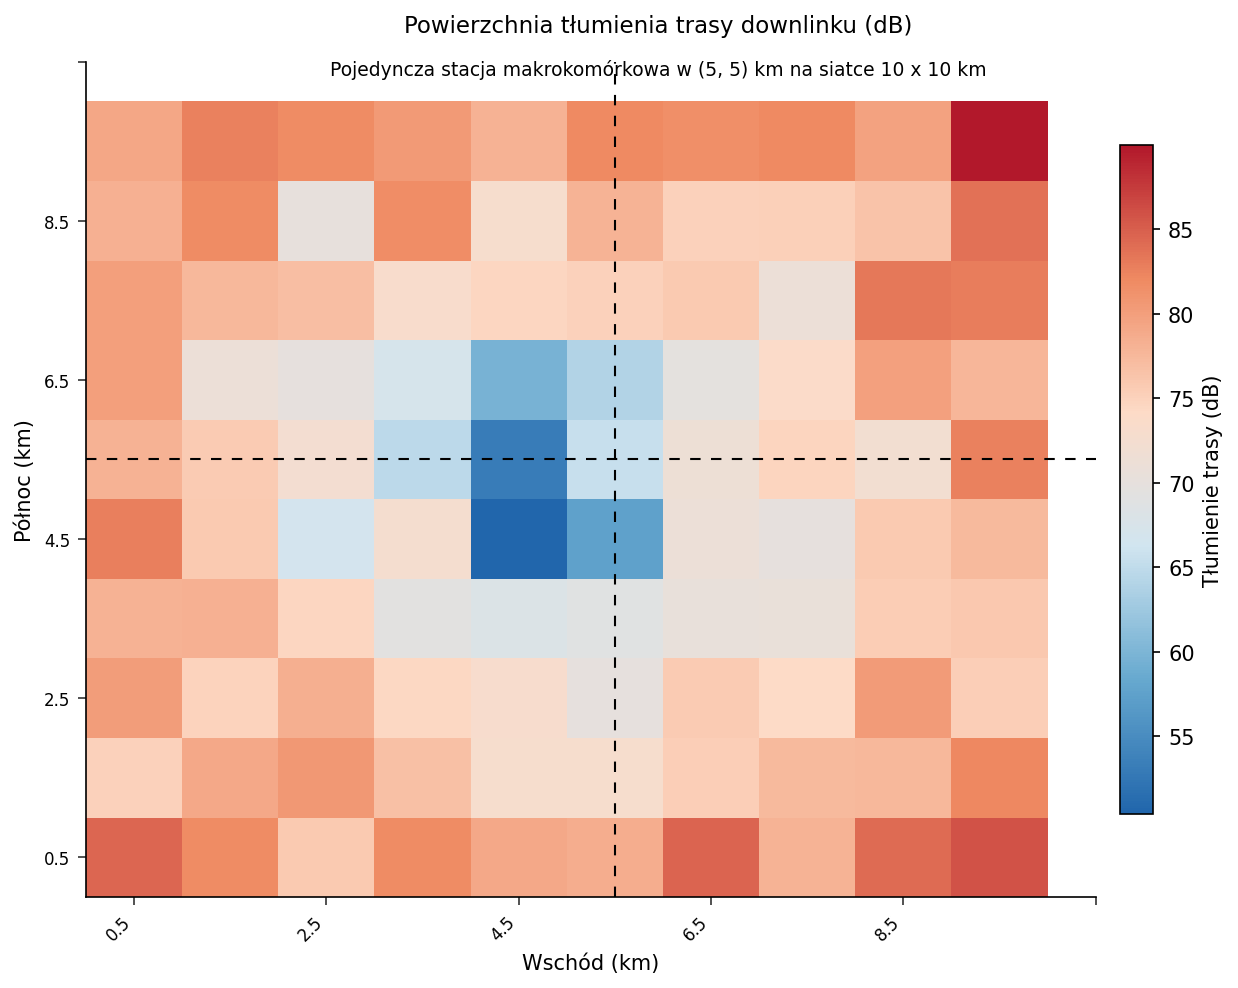

In [4]:
ODS GRAPHICS ON;
TYTUŁ "Powierzchnia tłumienia trasy downlinku (dB)";
title2 "Pojedyncza stacja makrokomórkowa w (5, 5) km na siatce 10 x 10 km";

PROCEDURA SGPLOT DANE=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / TYTUŁ="Tłumienie trasy (dB)";
   REFLINE 5 / AXIS=x LINEATTRS=(color=black pattern=shortdash);
   REFLINE 5 / AXIS=y LINEATTRS=(color=black pattern=shortdash);
   XAXIS VALUES=(0 2 4 6 8 10) ETYKIETA="Wschód (km)";
   YAXIS VALUES=(0 2 4 6 8 10) ETYKIETA="Północ (km)";
WYKONAJ;

TYTUŁ; title2;

## Krok 5 — Podział na klasy zasięgu

Slajd podsumowujący chce też nagłówkowy podział: jaka część śladu jest Silna, Umiarkowana lub Słaba. `VBAR` klasyfikacji `zone` pokazuje to od razu i uzupełnia powyższą powierzchnię konturową.


                                                Podział na klasy zasięgu                                                




NOTE: Option TITLE changed to Podział na klasy zasięgu.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


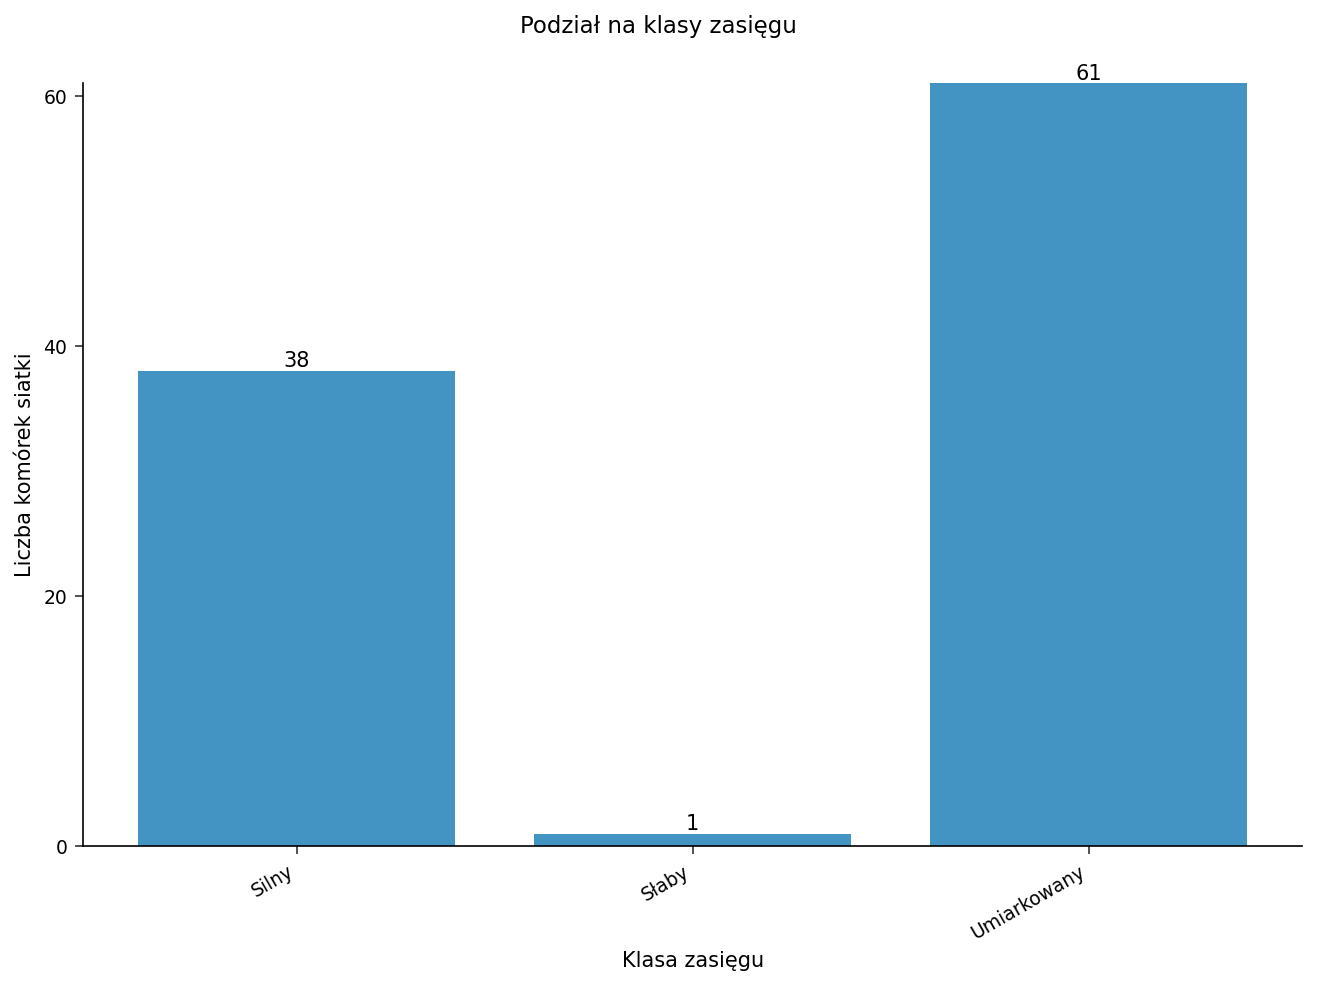

In [5]:
TYTUŁ "Podział na klasy zasięgu";

PROCEDURA SGPLOT DANE=pathloss_grid;
   VBAR zone / DATALABEL fillattrs=(color=CX4393C3) NOOUTLINE;
   XAXIS ETYKIETA="Klasa zasięgu";
   YAXIS ETYKIETA="Liczba komórek siatki" VALUES=(0 20 40 60);
WYKONAJ;

TYTUŁ;

## Interpretacja wyników

Powierzchnia konturowa potwierdza oczekiwaną fizykę propagacji. Tłumienie trasy jest najniższe w ciasnym **niebieskim zagłębieniu wokół wieży w (5, 5) km** — strefie Silny, gdzie odbierany sygnał jest najlepszy — i rośnie wraz z logarytmem odległości w kierunku rogów. Ponieważ wprowadziliśmy log-normalne cieniowanie, pasma nie są koncentrycznymi okręgami; postrzępione czerwone komórki wzdłuż granicy to krawędź zniekształcona przez cieniowanie.

Praktycznym wnioskiem jest **pojedyncza komórka Słaby w (9,5, 9,5) km (89,97 dB)** — róg leżący po przekątnej naprzeciw wieży i jedyny punkt przekraczający próg projektowy 88 dB. Przy **61 ze 100 komórek Umiarkowany i tylko 1 Słaby**, ta stacja makrokomórkowa dobrze pokrywa swój obszar usługowy; pojedyncza dziura uzasadniałaby **dobudowę small-cell lub przechylenie sektora w stronę północno-wschodniego rogu** tylko wtedy, gdyby pokrywała się ze znanym punktem wysokiego popytu. Powierzchnia konturowa to podsumowanie gotowe do prezentacji; wykres słupkowy klas zasięgu daje jedną liczbę, którą planista pojemności raportuje wyżej.